In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
from torchvision.models.feature_extraction import create_feature_extractor
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
from torchvision.models.feature_extraction import get_graph_node_names

backbone = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1)

train_nodes, eval_nodes = get_graph_node_names(backbone)
print("Trainable nodes:\n", train_nodes[:50])  # first 50
print("Eval nodes:\n", eval_nodes[:50])

Trainable nodes:
 ['x', 'features.0', 'features.1.block.0', 'features.1.block.1', 'features.1.block.2', 'features.2.block.0', 'features.2.block.1', 'features.2.block.2', 'features.3.block.0', 'features.3.block.1', 'features.3.block.2', 'features.3.add', 'features.4.block.0', 'features.4.block.1', 'features.4.block.2', 'features.4.block.3', 'features.5.block.0', 'features.5.block.1', 'features.5.block.2', 'features.5.block.3', 'features.5.add', 'features.6.block.0', 'features.6.block.1', 'features.6.block.2', 'features.6.block.3', 'features.6.add', 'features.7.block.0', 'features.7.block.1', 'features.7.block.2', 'features.7.block.3', 'features.8.block.0', 'features.8.block.1', 'features.8.block.2', 'features.8.block.3', 'features.8.add', 'features.9.block.0', 'features.9.block.1', 'features.9.block.2', 'features.9.block.3', 'features.10.block.0', 'features.10.block.1', 'features.10.block.2', 'features.10.block.3', 'features.10.add', 'features.11.block.0', 'features.11.block.1', 'featur

In [4]:
# load pretrained MobileNetV3-Small
backbone = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1).eval()

# we’ll extract some intermediate layers by name
return_nodes = {
    "features.0": "stem",  # very first conv layer
    "features.2.block.0": "early",  # early bottleneck conv
    "features.6.block.0": "mid",  # mid-level
    "features.10.block.0": "late",  # deeper stage
    "features.12": "final",  # last conv stage before pooling/classifier
}

feature_extractor = create_feature_extractor(backbone, return_nodes=return_nodes)

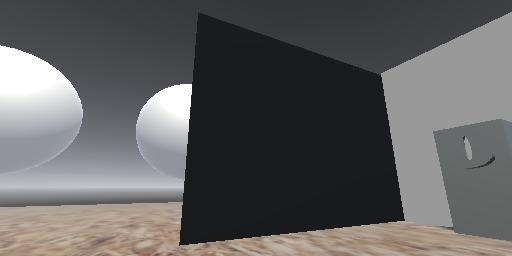

In [6]:
# make a dummy observation: (batch=1, channels=3, height=512, width=256)
from PIL import Image

# path to your visual observation image
img_path = "./obs_step.jpg"  # <-- replace with your file
img = Image.open(img_path).convert("RGB")
img

In [7]:
import torchvision.transforms as T

preprocess = T.Compose(
    [
        T.ToTensor(),  # (H, W, C) [0,1] -> (C, H, W)
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

obs = preprocess(img).unsqueeze(0)  # add batch dim: (1,3,H,W)
print("Obs shape:", obs.shape)

# same normalization as your Extractor
preprocess = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
obs = preprocess(obs)

Obs shape: torch.Size([1, 3, 256, 512])


In [8]:
with torch.no_grad():
    feats = feature_extractor(obs)

for k, v in feats.items():
    print(f"{k}: shape={v.shape}")

stem: shape=torch.Size([1, 16, 128, 256])
early: shape=torch.Size([1, 72, 64, 128])
mid: shape=torch.Size([1, 240, 16, 32])
late: shape=torch.Size([1, 576, 8, 16])
final: shape=torch.Size([1, 576, 8, 16])


In [9]:
def plot_feature_maps(feat_tensor, num_channels=6, title=""):
    """
    feat_tensor: torch.Tensor (1, C, H, W)
    num_channels: how many channels to show
    """
    feat_tensor = feat_tensor.squeeze(0)  # remove batch
    C = feat_tensor.shape[0]
    num_channels = min(num_channels, C)

    fig, axes = plt.subplots(1, num_channels, figsize=(15, 5))
    for i in range(num_channels):
        fm = feat_tensor[i].cpu().numpy()
        fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)  # normalize [0,1]
        axes[i].imshow(fm, cmap="viridis")
        axes[i].axis("off")
        axes[i].set_title(f"ch {i}")
    plt.suptitle(title)
    plt.show()

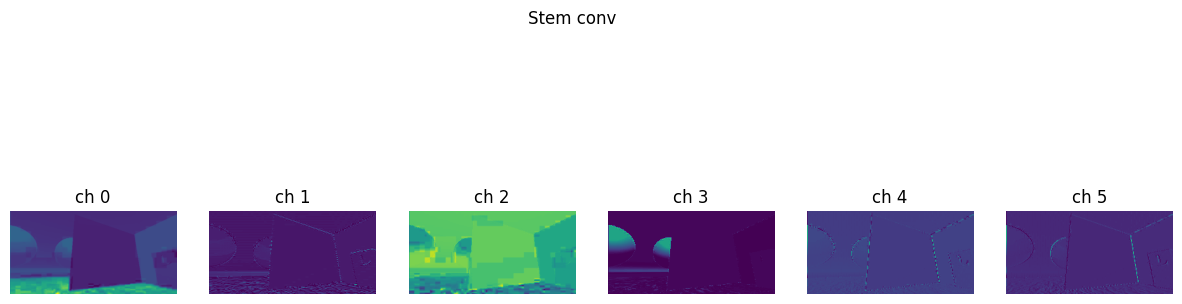

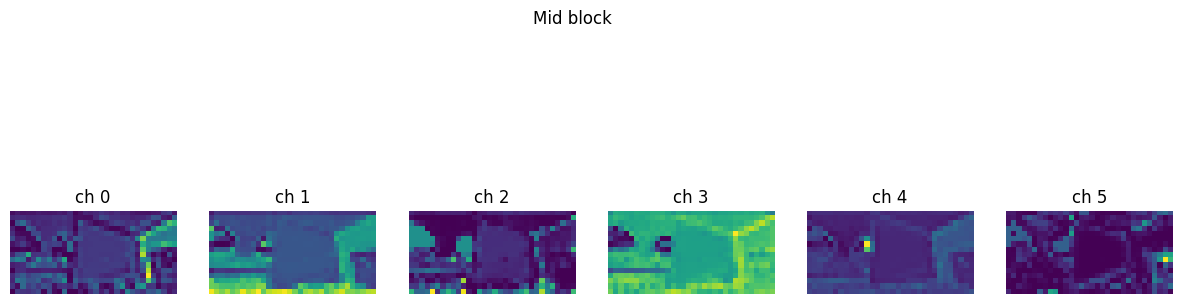

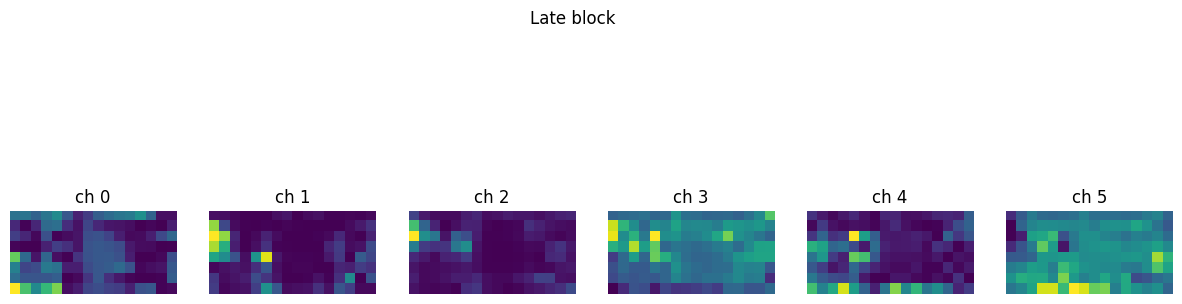

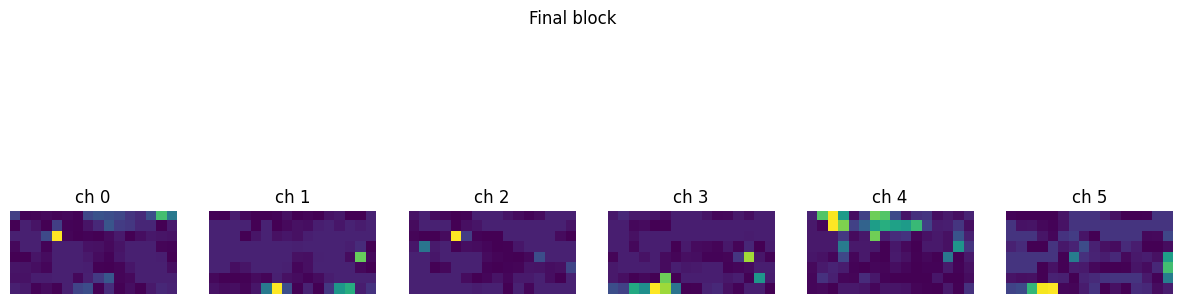

In [14]:
plot_feature_maps(feats["stem"], title="Stem conv")
# plot_feature_maps(feats["early"], title="Early block")
plot_feature_maps(feats["mid"], title="Mid block")
plot_feature_maps(feats["late"], title="Late block")
plot_feature_maps(feats["final"], title="Final block")